# Layer 1 Model Comparison — Cascade Phish Guard

Comparing four classifiers (Logistic Regression, Random Forest, XGBoost, MLP) trained on the same Layer 1 URL feature set, following the same preprocessing (`scripts/training/common.py`) so the comparison reflects only the algorithm, not accidental differences in inputs.

**Scope note:** as with the EDA notebook, this run is on a small, deliberately class balanced placeholder batch (all confirmed phishing collected so far + a modest random legitimate sample)  built to validate the full training + comparison pipeline end-to-end before the dataset collection window closes. The same notebook will be rerun unchanged against the full dataset; treat specific numbers here as provisional, not final.

In [1]:
import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve

sys.path.insert(0, "../scripts/training")
from common import prepare_features

MODELS = ["logistic_regression", "random_forest", "xgboost", "mlp"]

results = {}
for name in MODELS:
    with open(f"../data/reports/{name}_results.json") as f:
        results[name] = json.load(f)

with open("../data/reports/layer1_model_comparison.json") as f:
    comparison = json.load(f)

## Validation comparison — all four models

,accuracy,precision,recall,f1,auc_roc
model,,,,,
logistic_regression,1.000000,1.0,1.000000,1.0,1.000000
random_forest,1.000000,1.0,1.000000,1.0,1.000000
xgboost,1.000000,1.0,1.000000,1.0,1.000000
mlp,0.981132,1.0,0.666667,0.8,0.986667


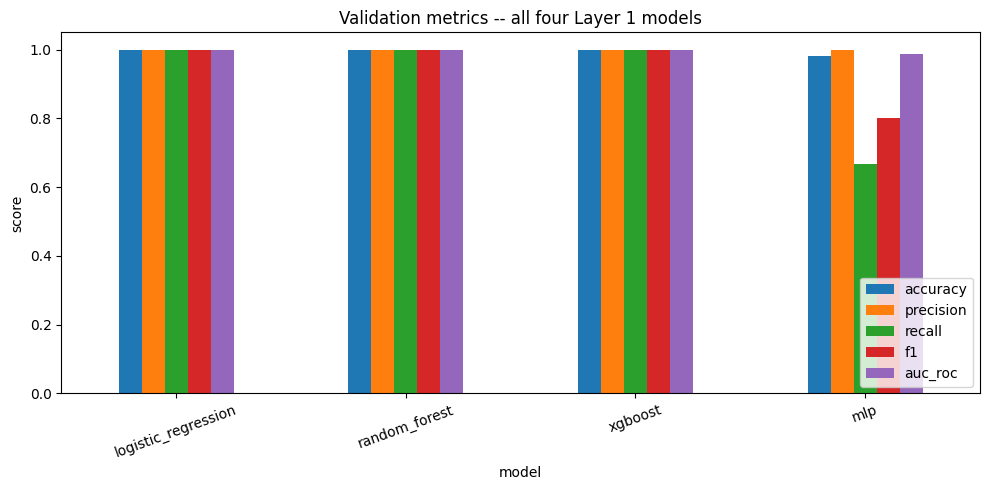

In [2]:
comparison_df = pd.DataFrame(comparison["comparison_table"]).set_index("model")
display(comparison_df)

comparison_df[["accuracy", "precision", "recall", "f1", "auc_roc"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1.05)
)
plt.title("Validation metrics -- all four Layer 1 models")
plt.ylabel("score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## ROC curves (validation set), overlaid

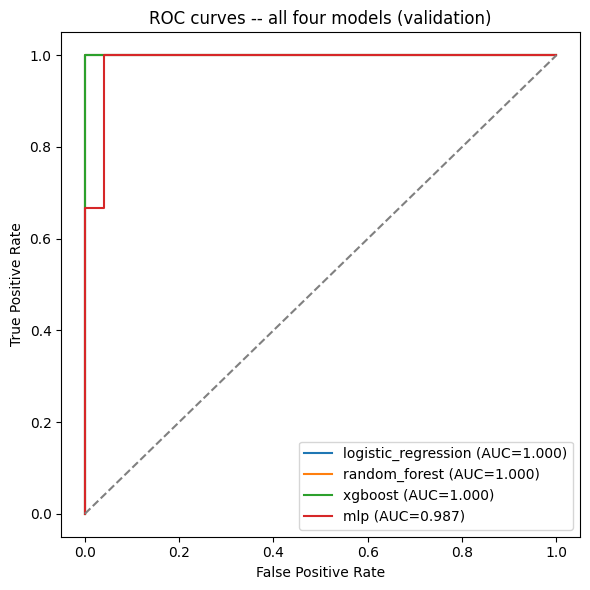

In [3]:
val = pd.read_csv("../data/processed/layer1_validation_features.csv")

plt.figure(figsize=(6, 6))
for name in MODELS:
    artifact = joblib.load(f"../data/models/{name}.joblib")
    model = artifact["model"]
    median_domain_age = artifact["median_domain_age"]
    X_val = prepare_features(val, median_domain_age)
    if "scaler" in artifact:
        X_val = artifact["scaler"].transform(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(val["label"], y_proba)
    auc = results[name]["metrics"]["auc_roc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves -- all four models (validation)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Winner selection and test-set confirmation

The winner is picked using validation performance only (F1, ties broken by preferring the simpler/more interpretable model). The test set untouched by every model until this exact step  is then used **once**, purely to confirm the winner, never to choose between models.

In [4]:
print("Winner:", comparison["winner"])
print("Selected via tie-break:", comparison["winner_selected_via_tiebreak"])
if comparison["tie_break_reasoning"]:
    print("Reasoning:", comparison["tie_break_reasoning"])

print()
winner_val_metrics = comparison_df.loc[comparison["winner"]]
test_metrics = comparison["test_set_confirmation"]["metrics"]

side_by_side = pd.DataFrame({"validation": winner_val_metrics, "test": test_metrics})
display(side_by_side)

Winner: logistic_regression
Selected via tie-break: True
Reasoning: Occam's razor -- when validation performance ties, prefer the simpler/more interpretable model (order: logistic_regression > random_forest > xgboost > mlp).



,validation,test
accuracy,1.0,0.945455
precision,1.0,1.000000
recall,1.0,0.400000
f1,1.0,0.571429
auc_roc,1.0,1.000000


**Note the gap between validation and test performance above.** This is expected and worth discussing rather than hiding: validation numbers on a very small sample can look stronger than they really are, and the held out test set is what actually reveals the model's true current limits in this case, traced to too few phishing training examples so far (17), not a bug. This gap is expected to close as the dataset grows.

## Feature importance / coefficients comparison

MLP has no direct equivalent (neural network weights aren't as directly interpretable as tree splits or linear coefficients), so it's excluded from this comparison.

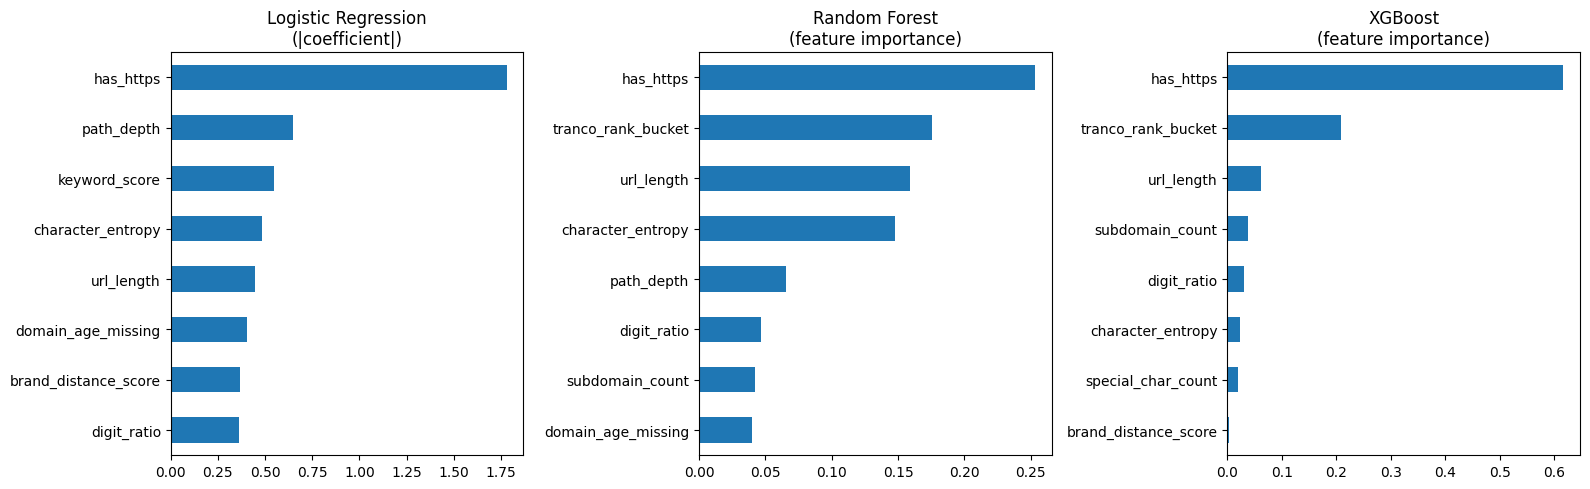

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lr_coefs = pd.Series(results["logistic_regression"]["coefficients"]).abs().sort_values(ascending=False).head(8)
lr_coefs.plot(kind="barh", ax=axes[0], title="Logistic Regression\n(|coefficient|)")

rf_imps = pd.Series(results["random_forest"]["feature_importances"]).sort_values(ascending=False).head(8)
rf_imps.plot(kind="barh", ax=axes[1], title="Random Forest\n(feature importance)")

xgb_imps = pd.Series(results["xgboost"]["feature_importances"]).sort_values(ascending=False).head(8)
xgb_imps.plot(kind="barh", ax=axes[2], title="XGBoost\n(feature importance)")

for ax in axes:
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Key findings from this development phase

- **Three different models independently agree `has_https` is the strongest single signal** Logistic Regression's largest coefficient, and both tree-based models' top feature importance, despite the three algorithms working in completely different ways. Independent agreement across model families is a stronger signal than any one model's result alone.
- **A recurring feature-engineering issue was found and fixed three times during this phase**: free hosting/content-gateway platforms (Vercel, Blogspot, IPFS gateways, and a free web-hosting service) were inheriting their own long-established domain reputation and age, even when a phishing page was freely hosted under them. Each instance was confirmed on real data and fixed the same way worth discussing as a designed-for failure mode in the methodology chapter, with a noted long-term direction (adopting the community-maintained Public Suffix List) rather than continuing to patch services one at a time.
- **The validation/test performance gap for the current winner is a genuine, expected artifact of the current tiny training set** (17 phishing examples), not a remaining bug confirmed by checking the specific missed cases directly, which had low (not borderline) predicted phishing probability.

## Summary and next steps

- All four required models are trained, evaluated identically, and compared.
- Current winner: see above expected to be re-decided once the full dataset is in, since three of four models are currently tied.
- Next: Phase 5 (Layer 2 DOM analysis), while the dataset collection window remains open in the background and this comparison gets re run at full scale before final submission.